In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gseapy as gp


In [2]:
results_df = pd.read_csv('/itf-fi-ml/shared/users/ziyuzh/svm/results/all_metrics_1and2percent.csv')

In [3]:
root = '/itf-fi-ml/shared/users/ziyuzh/svm/results/df_gnn_occsvm_pred'

# Load mapping dictionary
with open('/itf-fi-ml/shared/users/ziyuzh/svm/data/uniport_id/uni2name.pkl', 'rb') as file:
    uni2name_dict = pickle.load(file)

def enriched_set(input_ids):
    gene_names = set()
    for unid in input_ids:
        gene_list = uni2name_dict.get(unid, [])
        gene_names.update(gene_list)
    gene_names = list(gene_names)

    enrich_db = [
        'GO_Biological_Process_2021',
        'GO_Cellular_Component_2021',
        'GO_Molecular_Function_2021',
        'KEGG_2019_Human',
        'Reactome_2022'
    ]

    try:
        enr = gp.enrichr(
            gene_list=gene_names,
            gene_sets=enrich_db,
            organism='human',
            outdir=None
        )
        enr_df = enr.results
        if enr_df is None or enr_df.empty:
            return set()

        result_terms = enr_df.loc[
            enr_df['Adjusted P-value'] < 0.01]
        return result_terms

    except Exception as e:
        print(f"Enrichment failed: {e}") 

In [4]:
def get_true_positive_ranks(data, pred):
    """
    data format:
    {
        'true_label': [0,1,0,...],
        'test_genes': [...],
        'pred_scores': [...]
    }

    Returns:
        [(gene_name, rank_position, score), ...]
    """

    true_label = data['true_label']
    test_genes = data['test_genes']
    pred_scores = data[pred]

    # Combine everything
    combined = list(zip(test_genes, pred_scores, true_label))

    # Sort by prediction score descending
    combined_sorted = sorted(
        combined,
        key=lambda x: x[1],
        reverse=True
    )

    results = []

    for rank, (gene, score, label) in enumerate(combined_sorted, start=1):
        if label == 1:
            results.append((gene, uni2name_dict[gene], rank))

    return results

def enrich_pred(data, pred, cutoff):
    test_indices = data['test_genes']
    final_y_score = data[pred]
    enrich_predict_genes = test_indices[np.argsort(final_y_score)[::-1]][:cutoff]
    return enriched_set(enrich_predict_genes)

def top_gene_sim(data, p1,p2,cutoff):
    test_indices = data['test_genes']
    genes1 = test_indices[np.argsort(data[p1])[::-1]][:cutoff]
    genes2 = test_indices[np.argsort(data[p2])[::-1]][:cutoff]
    return set(set(genes1)&set(genes2))

def calculate_jac_sim(enrich_1, enrich_2):
    intersection = enrich_1 & enrich_2
    union = enrich_1 | enrich_2
    if not union:
        return 0.0  # similarity = 0 if both sets are empty
    return len(intersection) / len(union)

def general_report(data,p1,p2,cutoff):
    print(p1+" TP position: ", get_true_positive_ranks(data, p1))
    print(p2+" TP position: ", get_true_positive_ranks(data, p2))
    print('overlaps gene numbers between top predictions: ', len(top_gene_sim(data, p1,p2,cutoff)))

    train_genes = data['train_pos_genes']
    print('train positive numbers: ', len(train_genes))

    enrich_train = enriched_set(train_genes)
    enrich_p1 = enrich_pred(data,p1,cutoff)
    enrich_p2 = enrich_pred(data, p2,cutoff)

    overlap_terms_t_p1 = set(enrich_train['Term']) & set(enrich_p1['Term'])
    overlap_terms_t_p2 = set(enrich_train['Term']) & set(enrich_p2['Term'])
    overlap_terms_p1_p2 = set(enrich_p1['Term']) & set(enrich_p2['Term'])
    print(f'overlap train enrich & {p1} enrich',len(overlap_terms_t_p1),'\n',
          f'overlap train enrich & {p2} enrich',len(overlap_terms_t_p2),'\n',
          f'overlap {p1} enrich & {p2} enrich',len(overlap_terms_p1_p2))    
    return enrich_train,enrich_p1,enrich_p2,overlap_terms_t_p1,overlap_terms_t_p2,overlap_terms_p1_p2

# blood analysis
>Why is BioSim weak for “Diseases of the Blood and Certain Disorders”? Biosim vs recall/bedroc/auroc

In [ ]:
blood_df = results_df[results_df['category']=='Diseases of the blood and certain disorders(3)']
fuse_df = blood_df[
    (blood_df["setting"] == "df_gnn_occsvm_pred") &
    (blood_df["method"].str.contains("fuse", na=False))
].copy()

In [6]:

# Filter data
df = blood_df[
    (blood_df["setting"] == "df_gnn_occsvm_pred") &
    (blood_df["method"].str.contains("fuse", na=False))
].copy()

metrics = [
    "bio_sim_300", "bio_sim_150",
    "top_recall_150", "succ_150",
    "top_recall_300", "succ_300",
    "bedroc_150", "bedroc_300",
    "auroc"
]

# ---------------------------------------------------
# Convert metric values into ranks within each disease
# across methods
# ---------------------------------------------------

rank_df = df.copy()

for metric in metrics:
    rank_df[f"{metric}_rank"] = (
        rank_df.groupby("disease")[metric]
        .rank(
            method="average",   # tie handling
            ascending=False     # larger metric = better rank
        )
    )

# ---------------------------------------------------
# Optional: integer ranks
# ---------------------------------------------------

for metric in metrics:
    rank_df[f"{metric}_rank_int"] = (
        rank_df.groupby("disease")[metric]
        .rank(
            method="min",
            ascending=False
        )
        .astype(int)
    )

# ---------------------------------------------------
# Example output
# ---------------------------------------------------

rank_columns = (
    ["disease", "method"] +
    [f"{m}_rank" for m in metrics]
)

In [7]:
results_df['bio_sim_150'].max(),results_df['bio_sim_150'].min(),results_df['bio_sim_300'].max(),results_df['bio_sim_300'].min()

(0.355281207133059, 0.0, 0.3781376518218624, 0.0)

In [8]:
fuse_df[['disease', 'method', 'bio_sim_150','bio_sim_300', 'top_recall_150', 'top_recall_300','succ_150', 'succ_300', 'bedroc_150','bedroc_300', 'auroc']].round(3)

,disease,method,bio_sim_150,bio_sim_300,top_recall_150,top_recall_300,succ_150,succ_300,bedroc_150,bedroc_300,auroc
374,ICD10_D66,early_fused,0.119,0.099,1.0,1.0,1,1,0.557,0.746,0.996
375,ICD10_D66,early_fused_ppi,0.111,0.091,1.0,1.0,1,1,0.713,0.844,0.998
376,ICD10_D66,late_fused,0.112,0.092,1.0,1.0,1,1,0.931,0.965,1.000
377,ICD10_D66,late_fused_ppi,0.092,0.079,1.0,1.0,1,1,0.766,0.875,0.998
384,ICD10_D66,mid_linear_fused,0.101,0.082,1.0,1.0,1,1,0.840,0.916,0.999
385,ICD10_D66,mid_geo_fused,0.107,0.090,1.0,1.0,1,1,0.866,0.931,0.999
386,ICD10_D66,mid_linear_fused_ppi,0.090,0.078,1.0,1.0,1,1,0.774,0.880,0.998
387,ICD10_D66,mid_geo_fused_ppi,0.072,0.063,1.0,1.0,1,1,0.677,0.823,0.998
1122,ICD10_D83,early_fused,0.089,0.079,0.0,0.0,0,0,0.000,0.000,0.444
1123,ICD10_D83,early_fused_ppi,0.100,0.068,0.0,0.0,0,0,0.000,0.001,0.846


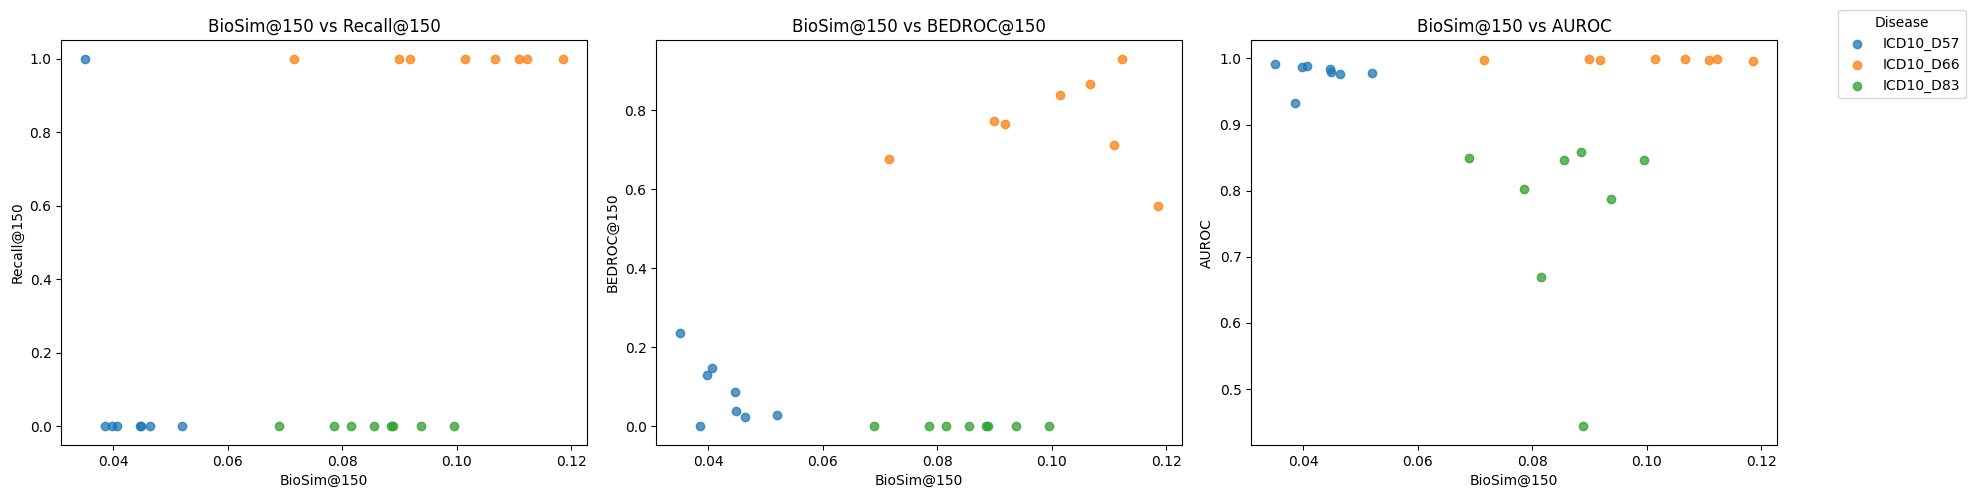

In [11]:
import matplotlib.pyplot as plt

plot_df = fuse_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

metric_pairs = [
    ("top_recall_150", "Recall@150"),
    ("bedroc_150", "BEDROC@150"),
    ("auroc", "AUROC")
]

for ax, (metric, ylabel) in zip(axes, metric_pairs):

    for disease, sub in plot_df.groupby("disease"):
        ax.scatter(
            sub["bio_sim_150"],
            sub[metric],
            label=disease,
            alpha=0.75
        )

    ax.set_xlabel("BioSim@150")
    ax.set_ylabel(ylabel)
    ax.set_title(f"BioSim@150 vs {ylabel}")

# single shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Disease",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

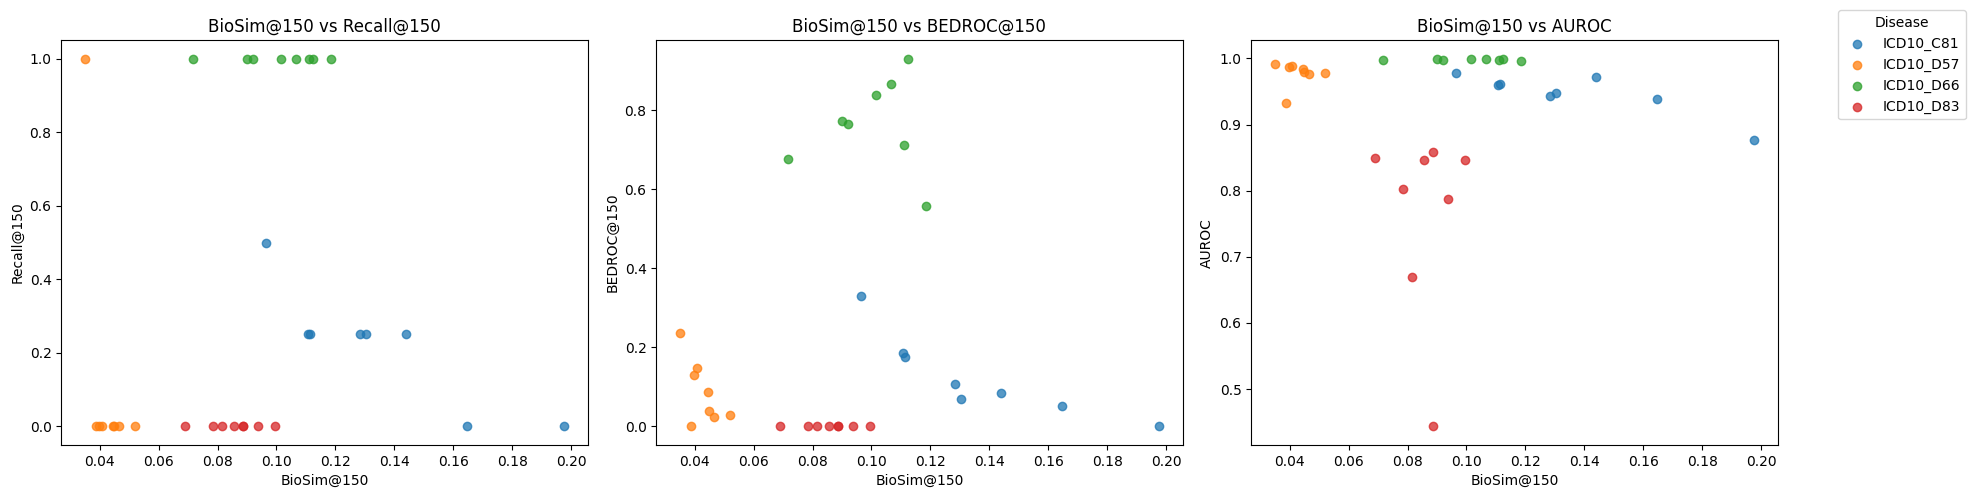

In [14]:
select_disease = ['ICD10_D66','ICD10_D83','ICD10_D57','ICD10_C81']
selec_df = results_df[(results_df['disease'].isin(select_disease))&(results_df["setting"] == "df_gnn_occsvm_pred")&(results_df["method"].str.contains("fuse", na=False))].copy()


plot_df = selec_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

metric_pairs = [
    ("top_recall_150", "Recall@150"),
    ("bedroc_150", "BEDROC@150"),
    ("auroc", "AUROC")
]

for ax, (metric, ylabel) in zip(axes, metric_pairs):

    for disease, sub in plot_df.groupby("disease"):
        ax.scatter(
            sub["bio_sim_150"],
            sub[metric],
            label=disease,
            alpha=0.75
        )

    ax.set_xlabel("BioSim@150")
    ax.set_ylabel(ylabel)
    ax.set_title(f"BioSim@150 vs {ylabel}")

# single shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Disease",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [9]:
rank_df[rank_columns]

,disease,method,bio_sim_300_rank,bio_sim_150_rank,top_recall_150_rank,succ_150_rank,top_recall_300_rank,succ_300_rank,bedroc_150_rank,bedroc_300_rank,auroc_rank
374,ICD10_D66,early_fused,1.0,1.0,4.5,4.5,4.5,4.5,8.0,8.0,8.0
375,ICD10_D66,early_fused_ppi,3.0,3.0,4.5,4.5,4.5,4.5,6.0,6.0,6.0
376,ICD10_D66,late_fused,2.0,2.0,4.5,4.5,4.5,4.5,1.0,1.0,1.0
377,ICD10_D66,late_fused_ppi,6.0,6.0,4.5,4.5,4.5,4.5,5.0,5.0,5.0
384,ICD10_D66,mid_linear_fused,5.0,5.0,4.5,4.5,4.5,4.5,3.0,3.0,3.0
385,ICD10_D66,mid_geo_fused,4.0,4.0,4.5,4.5,4.5,4.5,2.0,2.0,2.0
386,ICD10_D66,mid_linear_fused_ppi,7.0,7.0,4.5,4.5,4.5,4.5,4.0,4.0,4.0
387,ICD10_D66,mid_geo_fused_ppi,8.0,8.0,4.5,4.5,4.5,4.5,7.0,7.0,7.0
1122,ICD10_D83,early_fused,1.0,3.0,4.5,4.5,4.5,4.5,8.0,8.0,8.0
1123,ICD10_D83,early_fused_ppi,3.0,1.0,4.5,4.5,4.5,4.5,2.0,2.0,4.0


## D66/D83 - same recall, different biosim

### D66 - recall@150/300=1, auroc similar high, biosim vs bedroc 
> early_fuse vs mid_geo_fused_ppi

In [10]:
file_path = os.path.join(root, 'ICD10_D66_pred.pkl')
disease_record = dict()

with open(file_path, "rb") as f:
    data_D66 = pickle.load(f)

fuse_df[(fuse_df['disease']=='ICD10_D66')][['method', 'bio_sim_150','bio_sim_300', 'top_recall_150', 'top_recall_300', 'bedroc_150','bedroc_300', 'auroc']].round(3)

,method,bio_sim_150,bio_sim_300,top_recall_150,top_recall_300,bedroc_150,bedroc_300,auroc
374,early_fused,0.119,0.099,1.0,1.0,0.557,0.746,0.996
375,early_fused_ppi,0.111,0.091,1.0,1.0,0.713,0.844,0.998
376,late_fused,0.112,0.092,1.0,1.0,0.931,0.965,1.000
377,late_fused_ppi,0.092,0.079,1.0,1.0,0.766,0.875,0.998
384,mid_linear_fused,0.101,0.082,1.0,1.0,0.840,0.916,0.999
385,mid_geo_fused,0.107,0.090,1.0,1.0,0.866,0.931,0.999
386,mid_linear_fused_ppi,0.090,0.078,1.0,1.0,0.774,0.880,0.998
387,mid_geo_fused_ppi,0.072,0.063,1.0,1.0,0.677,0.823,0.998


In [12]:
enrich_train, enrich_early ,enrich_geo_ppi , enrich_overlap_t_p1, enrich_overlap_t_p2,enrich_overlap_p2_p1= general_report(data_D66,'early_fused','mid_geo_fused_ppi',150)

early_fused TP position:  [('P00750', ['PLAT'], 58)]
mid_geo_fused_ppi TP position:  [('P00750', ['PLAT'], 39)]
overlaps gene numbers between top predictions:  44
train positive numbers:  14
overlap train enrich & early_fused enrich 73 
 overlap train enrich & mid_geo_fused_ppi enrich 85 
 overlap early_fused enrich & mid_geo_fused_ppi enrich 377


In [14]:
data_D66['train_pos_genes']

Index(['P00451', 'P00734', 'P00740', 'P01137', 'P01579', 'P01909', 'P04275',
       'P09601', 'P10646', 'P12318', 'P22301', 'P42898', 'P49257', 'Q9BWH2'],
      dtype='object', name='string_id')

In [13]:
enrich_train

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,negative regulation of smooth muscle cell prol...,3/33,0.000001,0.000849,0,0,181.418182,2436.336634,IL10;IFNG;HMOX1
1,GO_Biological_Process_2021,negative regulation of blood coagulation (GO:0...,3/40,0.000003,0.000849,0,0,147.044226,1887.824640,F8;F2;TFPI
2,GO_Biological_Process_2021,endoplasmic reticulum to Golgi vesicle-mediate...,4/185,0.000007,0.001405,0,0,43.767956,522.097940,LMAN1;F8;F9;F2
3,GO_Biological_Process_2021,positive regulation of protein localization to...,3/68,0.000013,0.002087,0,0,83.584615,938.337371,TGFB1;IFNG;F2
4,GO_Biological_Process_2021,negative regulation of protein activation casc...,2/9,0.000016,0.002087,0,0,475.690476,5243.183292,F8;TFPI
...,...,...,...,...,...,...,...,...,...,...
805,Reactome_2022,Interleukin-12 Family Signaling R-HSA-447115,2/54,0.000638,0.004302,0,0,63.891026,470.085599,IL10;IFNG
806,Reactome_2022,"Platelet Activation, Signaling And Aggregation...",3/254,0.000664,0.004302,0,0,21.443318,156.895688,F8;TGFB1;VWF
807,Reactome_2022,COPII-mediated Vesicle Transport R-HSA-204005,2/66,0.000951,0.005881,0,0,51.880208,360.964054,LMAN1;F8
808,Reactome_2022,Immune System R-HSA-168256,6/1943,0.001259,0.007445,0,0,6.988513,46.664527,IL10;TGFB1;FCGR2A;IFNG;HMOX1;HLA-DQA1


In [92]:
enrich_early_fused[enrich_early_fused['Genes'].str.contains('PLAT')]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
22,GO_Biological_Process_2021,negative regulation of blood coagulation (GO:0...,13/40,1.544564e-18,1.176555e-16,0,0,69.158884,2836.329614,FGB;F10;F11;FGG;PDGFB;PDGFA;PLAT;PLG;F7;PROC;P...
41,GO_Biological_Process_2021,plasminogen activation (GO:0031639),6/9,1.381523e-11,5.762926e-10,0,0,273.737931,6844.885197,FGB;PLAU;F11;FGG;PLAT;KLKB1
43,GO_Biological_Process_2021,cellular protein metabolic process (GO:0044267),20/417,5.247058e-11,2.089283e-09,0,0,7.480531,177.069928,IGFBP1;ERO1A;APP;SERPIND1;IGFBP5;FGG;APOA2;APO...
50,GO_Biological_Process_2021,zymogen activation (GO:0031638),8/45,1.490479e-09,5.120233e-08,0,0,29.955774,608.826197,FGB;KLK1;PLAU;F11;FGG;HP;PLAT;KLKB1
67,GO_Biological_Process_2021,fibrinolysis (GO:0042730),5/15,6.484967e-08,1.646618e-06,0,0,67.941781,1124.517595,FGB;PLAU;FGG;PLAT;PLG
102,GO_Biological_Process_2021,proteolysis (GO:0006508),12/287,1.929055e-06,3.281267e-05,0,0,6.144879,80.857268,F7;PROC;PLAU;HGF;MMP3;KLK4;PLAT;CTSG;PLG;KLKB1...
152,GO_Biological_Process_2021,cellular protein modification process (GO:0006...,21/1025,2.982617e-05,3.415389e-04,0,0,3.032064,31.594485,IGFBP1;ERO1A;APP;TGFB2;SERPIND1;IGFBP5;FGG;PDG...
209,GO_Biological_Process_2021,platelet-derived growth factor receptor signal...,3/16,2.198059e-04,1.825118e-03,0,0,30.929314,260.510365,PDGFB;PDGFA;PLAT
217,GO_Biological_Process_2021,transmembrane receptor protein tyrosine kinase...,11/404,2.558203e-04,2.055951e-03,0,0,3.889786,32.172553,GH1;ANGPT2;ANGPT1;CSH2;BDNF;HGF;NTF3;PDGFB;PDG...
1759,GO_Cellular_Component_2021,collagen-containing extracellular matrix (GO:0...,19/380,8.146173e-11,1.089551e-09,0,0,7.770335,180.511779,FGB;TGFB2;ANGPT2;ANGPT1;AMBP;TGFB3;FGG;IFNA2;P...


In [93]:
enrich_mid_geo_fused_ppi[enrich_mid_geo_fused_ppi['Genes'].str.contains('PLAT')]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
25,GO_Biological_Process_2021,negative regulation of blood coagulation (GO:0...,13/40,1.413366e-18,1.277465e-16,0,0,69.667207,2863.361067,EDN1;F10;SERPINE1;SERPINF2;PLAT;PLG;F3;THBD;VT...
60,GO_Biological_Process_2021,cellular protein metabolic process (GO:0044267),22/417,6.891990e-13,2.655111e-11,0,0,8.465388,237.058336,APP;SERPINA1;CSF1;MMP1;SERPINC1;IGFBP3;MMP2;TN...
73,GO_Biological_Process_2021,proteolysis (GO:0006508),18/287,5.699900e-12,1.810103e-10,0,0,9.926157,256.993899,ACE;MMP1;HGF;MMP2;MMP3;KLK4;GZMB;PLAT;PLG;AZU1...
165,GO_Biological_Process_2021,fibrinolysis (GO:0042730),5/15,6.272856e-08,8.827073e-07,0,0,68.413793,1134.605063,PLAU;SERPINE1;SERPINF2;PLAT;PLG
168,GO_Biological_Process_2021,transmembrane receptor protein tyrosine kinase...,16/404,6.648303e-08,9.244682e-07,0,0,5.989229,98.979912,CSF1;HGF;MMP2;STAT3;IGF2;PLAT;IGF1;FGF2;MMP9;E...
207,GO_Biological_Process_2021,negative regulation of cellular protein metabo...,8/94,5.357604e-07,6.053063e-06,0,0,12.947265,186.953052,EDN1;AKT1;GZMB;PLAT;APOE;GAPDH;NFKB1;INS
303,GO_Biological_Process_2021,cellular protein modification process (GO:0006...,22/1025,8.238849e-06,6.368847e-05,0,0,3.229639,37.808255,APP;SERPINA1;CSF1;SERPINC1;IGFBP3;TNC;FN1;PLAT...
478,GO_Biological_Process_2021,negative regulation of proteolysis (GO:0045861),4/43,2.987931e-04,1.465895e-03,0,0,13.917106,112.947880,AKT1;PLAT;TIMP1;INS
489,GO_Biological_Process_2021,zymogen activation (GO:0031638),4/45,3.565713e-04,1.710087e-03,0,0,13.236886,105.087326,PLAU;HP;PLAT;OMA1
678,GO_Biological_Process_2021,plasminogen activation (GO:0031639),2/9,1.943227e-03,6.715564e-03,0,0,38.306950,239.165814,PLAU;PLAT


conclusion: D66 -  Hemophilia A , have a relatively clear disease mechanism <br>
both method can capture meaningful pathways, but the jaccard similarity calculation, especially the 'union' part lead to the differences in BioSim

### D83 - 0 recall, near 0 ebdroc, auroc diff, high biosim
> early_fused auroc=0.444, biosim@150=0.089

> late_fused_ppi auroc=0.858, biosim@150=0.089

In [15]:
file_path = os.path.join(root, 'ICD10_D83_pred.pkl')
disease_record = dict()

with open(file_path, "rb") as f:
    data_D83 = pickle.load(f)

fuse_df[(fuse_df['disease']=='ICD10_D83')][['method', 'bio_sim_150','bio_sim_300', 'top_recall_150', 'top_recall_300', 'bedroc_150','bedroc_300', 'auroc']].round(3)

,method,bio_sim_150,bio_sim_300,top_recall_150,top_recall_300,bedroc_150,bedroc_300,auroc
1122,early_fused,0.089,0.079,0.0,0.0,0.0,0.000,0.444
1123,early_fused_ppi,0.100,0.068,0.0,0.0,0.0,0.001,0.846
1124,late_fused,0.094,0.070,0.0,0.0,0.0,0.000,0.788
1125,late_fused_ppi,0.089,0.064,0.0,0.0,0.0,0.002,0.858
1132,mid_linear_fused,0.079,0.061,0.0,0.0,0.0,0.000,0.803
1133,mid_geo_fused,0.082,0.062,0.0,0.0,0.0,0.000,0.669
1134,mid_linear_fused_ppi,0.086,0.064,0.0,0.0,0.0,0.001,0.847
1135,mid_geo_fused_ppi,0.069,0.058,0.0,0.0,0.0,0.001,0.850


In [16]:
enrich_train, enrich_early ,enrich_late_ppi , enrich_overlap_t_p1, enrich_overlap_t_p2,enrich_overlap_p2_p1= general_report(data_D83,'early_fused','late_fused_ppi',150)

early_fused TP position:  [('P61619', ['SEC61A1'], 8575), ('Q96SD1', ['DCLRE1C'], 8857)]
late_fused_ppi TP position:  [('Q96SD1', ['DCLRE1C'], 1063), ('P61619', ['SEC61A1'], 3393)]
overlaps gene numbers between top predictions:  62
train positive numbers:  21
overlap train enrich & early_fused enrich 54 
 overlap train enrich & late_fused_ppi enrich 55 
 overlap early_fused enrich & late_fused_ppi enrich 373


In [17]:
enrich_train

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,B cell activation (GO:0042113),5/85,2.373687e-08,0.000005,0,0,77.730469,1364.654467,CR2;CD40LG;BTK;RAG2;MS4A1
1,GO_Biological_Process_2021,B cell proliferation (GO:0042100),4/32,3.167878e-08,0.000005,0,0,167.655462,2895.010593,CR2;CD40LG;CD19;MS4A1
2,GO_Biological_Process_2021,cytokine-mediated signaling pathway (GO:0019221),8/621,1.175465e-07,0.000013,0,0,19.441335,310.214346,CD40LG;TNFRSF13B;PRKCD;TNFSF13;IL21R;TNFRSF13C...
3,GO_Biological_Process_2021,B cell differentiation (GO:0030183),4/61,4.507569e-07,0.000038,0,0,82.237358,1201.680044,CR2;IRF2BP2;RAG2;MS4A1
4,GO_Biological_Process_2021,antigen receptor-mediated signaling pathway (G...,5/185,1.157459e-06,0.000078,0,0,34.373264,469.857902,CD19;BTK;MS4A1;NFKB1;HLA-DQB1
...,...,...,...,...,...,...,...,...,...,...
549,Reactome_2022,PKMTs Methylate Histone Lysines R-HSA-3214841,2/47,1.103204e-03,0.005921,0,0,46.629240,317.523525,NFKB1;NFKB2
550,Reactome_2022,Signaling By Interleukins R-HSA-449147,4/453,1.144602e-03,0.005945,0,0,10.234508,69.315239,IL21R;RAG2;NFKB1;NFKB2
551,Reactome_2022,"Nucleotide-binding Domain, Leucine Rich Repeat...",2/53,1.400981e-03,0.007049,0,0,41.131063,270.255049,NFKB1;NFKB2
552,Reactome_2022,Cytosolic Sensors Of Pathogen-Associated DNA R...,2/63,1.973063e-03,0.009626,0,0,34.371009,214.068429,NFKB1;NFKB2


In [18]:
enrich_early

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,cytokine-mediated signaling pathway (GO:0019221),59/621,1.589466e-49,1.958222e-46,0,0,22.251613,2500.264056,CD40;CD80;IL23R;FASLG;TNF;IL27RA;TNFSF13B;IL12...
1,GO_Biological_Process_2021,regulation of immune response (GO:0050776),35/179,5.043796e-40,3.106978e-37,0,0,41.649155,3768.633949,CD40;KLRB1;CD3G;KIR2DL1;CD3E;KIR2DL3;CD3D;SLAM...
2,GO_Biological_Process_2021,positive regulation of cytokine production (GO...,31/335,4.551725e-25,1.869242e-22,0,0,16.749392,938.788691,CD274;CD40;CD80;IL23R;CLEC9A;TNF;IL12B;SLAMF6;...
3,GO_Biological_Process_2021,regulation of T cell proliferation (GO:0042129),19/76,3.469370e-24,1.068566e-21,0,0,50.363868,2720.558885,TNFSF18;CD274;CD70;CD80;IL23R;SFTPD;PDCD1LG2;V...
4,GO_Biological_Process_2021,tumor necrosis factor-mediated signaling pathw...,21/116,1.973195e-23,4.861952e-21,0,0,33.851897,1769.770520,TNFSF18;CD40;TNFSF14;TNFSF15;CD70;TNFRSF9;TNFR...
...,...,...,...,...,...,...,...,...,...,...
1688,Reactome_2022,Interleukin-9 Signaling R-HSA-8985947,2/9,1.943227e-03,7.790735e-03,0,0,38.306950,239.165814,IL2RG;JAK1
1689,Reactome_2022,Cell-Cell Communication R-HSA-1500931,5/120,2.118540e-03,8.416381e-03,0,0,5.917541,36.434468,TYROBP;SIRPA;CLDN18;PTPN11;CD47
1690,Reactome_2022,RUNX1 And FOXP3 Control Development Of Regulat...,2/10,2.417101e-03,9.347551e-03,0,0,33.516892,201.945518,IL2RA;TNFRSF18
1691,Reactome_2022,STAT3 Nuclear Events Downstream Of ALK Signali...,2/10,2.417101e-03,9.347551e-03,0,0,33.516892,201.945518,CD274;IL2RG


In [19]:
enrich_early[enrich_early['Term'].isin(enrich_overlap_t_p1)]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,cytokine-mediated signaling pathway (GO:0019221),59/621,1.589466e-49,1.958222e-46,0,0,22.251613,2500.264056,CD40;CD80;IL23R;FASLG;TNF;IL27RA;TNFSF13B;IL12...
4,GO_Biological_Process_2021,tumor necrosis factor-mediated signaling pathw...,21/116,1.973195e-23,4.861952e-21,0,0,33.851897,1769.770520,TNFSF18;CD40;TNFSF14;TNFSF15;CD70;TNFRSF9;TNFR...
6,GO_Biological_Process_2021,positive regulation of T cell activation (GO:0...,17/75,6.066068e-21,1.067628e-18,0,0,43.617319,2030.454964,CD274;CD70;CD80;IL23R;HLA-A;PDCD1LG2;CD3E;ZAP7...
7,GO_Biological_Process_2021,antigen receptor-mediated signaling pathway (G...,22/185,2.391284e-20,3.682578e-18,0,0,20.758915,937.885104,BLK;HLA-DRB5;SYK;NFAM1;CD3G;VTCN1;HLA-A;CD3E;C...
9,GO_Biological_Process_2021,cellular response to tumor necrosis factor (GO...,22/194,6.848223e-20,8.437010e-18,0,0,19.663699,867.714066,TNFSF18;CD40;TNFSF14;CD70;TNFSF15;TNFRSF9;TNFR...
11,GO_Biological_Process_2021,positive regulation of lymphocyte proliferatio...,16/75,2.586872e-19,2.509596e-17,0,0,40.052618,1714.198684,CD274;CD40;CD70;CD80;IL23R;FCRL3;PDCD1LG2;CD3E...
24,GO_Biological_Process_2021,regulation of B cell proliferation (GO:0030888),10/46,1.345023e-12,6.628273e-11,0,0,39.313492,1074.618974,BLK;LYN;CD40;TYROBP;FCRL3;FCGR2B;IKZF3;TNFRSF4...
40,GO_Biological_Process_2021,regulation of B cell receptor signaling pathwa...,7/23,2.569936e-10,7.538478e-09,0,0,60.680944,1339.954789,BLK;LYN;PRKCH;FCRL3;NFAM1;FCGR2B;CD22
50,GO_Biological_Process_2021,B cell receptor signaling pathway (GO:0050853),7/34,5.263791e-09,1.271567e-07,0,0,35.939135,685.086682,BLK;CD79B;CD79A;TEC;SYK;LCK;NFAM1
61,GO_Biological_Process_2021,B cell activation (GO:0042113),9/85,1.494857e-08,2.954579e-07,0,0,16.607503,299.244783,CD79B;ZAP70;CD79A;CD40;BANK1;CD70;NFAM1;TCF3;CD22


In [20]:
enrich_late_ppi

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,cytokine-mediated signaling pathway (GO:0019221),83/621,3.626809e-85,4.718478e-82,0,0,43.811858,8518.399933,CD86;IL22;CSF3;CD40;CIITA;CSF2;ITGAM;CSF1;IFNA...
1,GO_Biological_Process_2021,cellular response to cytokine stimulus (GO:007...,52/482,6.165571e-46,4.010704e-43,0,0,23.720648,2469.317914,CD86;IL22;CSF3;CD40;CSF2;ITGAM;CSF1;IFNA1;IL26...
2,GO_Biological_Process_2021,regulation of immune response (GO:0050776),38/179,7.454390e-45,3.232720e-42,0,0,47.003326,4775.891717,CD40;KLRB1;ICAM3;CD1D;CXCL13;CD3E;ITGAL;KIR2DL...
3,GO_Biological_Process_2021,positive regulation of cytokine production (GO...,42/335,1.598533e-39,5.199229e-37,0,0,25.717882,2297.422956,CD86;CD274;CD40;CSF2;IL26;CD80;EBI3;IL27;DDX41...
4,GO_Biological_Process_2021,positive regulation of lymphocyte proliferatio...,26/75,5.200679e-37,1.353217e-34,0,0,84.048980,7022.028265,CD86;CD274;CD40;CD80;CD1D;CD3E;TNFSF13B;CD38;I...
...,...,...,...,...,...,...,...,...,...,...
1716,Reactome_2022,CD28 Co-Stimulation R-HSA-389356,3/34,2.126440e-03,8.121464e-03,0,0,12.958588,79.738155,CD86;LCK;CD80
1717,Reactome_2022,Gene And Protein Expression By JAK-STAT Signal...,3/35,2.313021e-03,8.728901e-03,0,0,12.552998,76.186667,IL10;IFNG;STAT4
1718,Reactome_2022,Interleukin-21 Signaling R-HSA-9020958,2/10,2.448892e-03,9.026730e-03,0,0,33.290268,200.145075,STAT1;STAT4
1719,Reactome_2022,STAT3 Nuclear Events Downstream Of ALK Signali...,2/10,2.448892e-03,9.026730e-03,0,0,33.290268,200.145075,CD274;PRDM1


In [21]:
enrich_early[enrich_early['Term'].isin(enrich_overlap_t_p1)]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,cytokine-mediated signaling pathway (GO:0019221),59/621,1.589466e-49,1.958222e-46,0,0,22.251613,2500.264056,CD40;CD80;IL23R;FASLG;TNF;IL27RA;TNFSF13B;IL12...
4,GO_Biological_Process_2021,tumor necrosis factor-mediated signaling pathw...,21/116,1.973195e-23,4.861952e-21,0,0,33.851897,1769.770520,TNFSF18;CD40;TNFSF14;TNFSF15;CD70;TNFRSF9;TNFR...
6,GO_Biological_Process_2021,positive regulation of T cell activation (GO:0...,17/75,6.066068e-21,1.067628e-18,0,0,43.617319,2030.454964,CD274;CD70;CD80;IL23R;HLA-A;PDCD1LG2;CD3E;ZAP7...
7,GO_Biological_Process_2021,antigen receptor-mediated signaling pathway (G...,22/185,2.391284e-20,3.682578e-18,0,0,20.758915,937.885104,BLK;HLA-DRB5;SYK;NFAM1;CD3G;VTCN1;HLA-A;CD3E;C...
9,GO_Biological_Process_2021,cellular response to tumor necrosis factor (GO...,22/194,6.848223e-20,8.437010e-18,0,0,19.663699,867.714066,TNFSF18;CD40;TNFSF14;CD70;TNFSF15;TNFRSF9;TNFR...
11,GO_Biological_Process_2021,positive regulation of lymphocyte proliferatio...,16/75,2.586872e-19,2.509596e-17,0,0,40.052618,1714.198684,CD274;CD40;CD70;CD80;IL23R;FCRL3;PDCD1LG2;CD3E...
24,GO_Biological_Process_2021,regulation of B cell proliferation (GO:0030888),10/46,1.345023e-12,6.628273e-11,0,0,39.313492,1074.618974,BLK;LYN;CD40;TYROBP;FCRL3;FCGR2B;IKZF3;TNFRSF4...
40,GO_Biological_Process_2021,regulation of B cell receptor signaling pathwa...,7/23,2.569936e-10,7.538478e-09,0,0,60.680944,1339.954789,BLK;LYN;PRKCH;FCRL3;NFAM1;FCGR2B;CD22
50,GO_Biological_Process_2021,B cell receptor signaling pathway (GO:0050853),7/34,5.263791e-09,1.271567e-07,0,0,35.939135,685.086682,BLK;CD79B;CD79A;TEC;SYK;LCK;NFAM1
61,GO_Biological_Process_2021,B cell activation (GO:0042113),9/85,1.494857e-08,2.954579e-07,0,0,16.607503,299.244783,CD79B;ZAP70;CD79A;CD40;BANK1;CD70;NFAM1;TCF3;CD22


In [22]:
pos_genes = data_D83['train_pos_genes'].tolist()
pos_genes.extend(['P61619','Q96SD1'])
enrich_pos = enriched_set(pos_genes)

In [23]:
enrich_pos[enrich_pos['Genes'].str.contains('SEC61A1|DCLRE1C')]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
463,KEGG_2019_Human,Primary immunodeficiency,8/37,2.926397e-17,2.867869e-15,0,0,366.859770,13966.415535,DCLRE1C;CD40LG;TNFRSF13B;CD19;BTK;TNFRSF13C;RA...
479,KEGG_2019_Human,Phagosome,3/152,6.816710e-04,3.929633e-03,0,0,19.961074,145.535460,SEC61A1;HLA-DQB1;MBL2
561,Reactome_2022,Immune System R-HSA-168256,16/1943,7.501509e-12,1.245250e-09,0,0,21.410038,548.437750,CR2;TNFRSF13B;CD81;PRKCD;TNFSF13;TNFRSF13C;NFK...
567,Reactome_2022,Adaptive Immune System R-HSA-1280218,7/733,1.265848e-05,3.001868e-04,0,0,11.600981,130.826392,SEC61A1;CD40LG;CD81;CD19;BTK;ICOS;NFKB1


In [24]:
all_pos_enrich = enrich_pos[enrich_pos['Genes'].str.contains('SEC61A1|DCLRE1C')]['Term']
enrich_train[enrich_train['Term'].isin(all_pos_enrich)]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
426,KEGG_2019_Human,Primary immunodeficiency,7/37,4.630337e-15,4.352517e-13,0,0,332.483333,10973.993678,CD40LG;TNFRSF13B;CD19;BTK;TNFRSF13C;RAG2;ICOS
520,Reactome_2022,Immune System R-HSA-168256,15/1943,1.896637e-11,3.053586e-09,0,0,23.406380,577.864975,CR2;TNFRSF13B;CD81;PRKCD;TNFSF13;TNFRSF13C;NFK...
531,Reactome_2022,Adaptive Immune System R-HSA-1280218,6/733,8.035912e-05,1.078151e-03,0,0,10.592572,99.877417,CD40LG;CD81;CD19;BTK;ICOS;NFKB1


In [25]:
enrich_early[enrich_early['Term'].isin(all_pos_enrich)]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
1447,KEGG_2019_Human,Primary immunodeficiency,11/37,2.105195e-15,1.673076e-14,0,0,60.338683,2039.107663,CD79A;ZAP70;CD40;CD4;CD8B;LCK;CD8A;IL2RG;CD3E;...
1451,KEGG_2019_Human,Phagosome,15/152,5.448956e-13,3.577358e-12,0,0,15.987835,451.467384,HLA-DRB5;SFTPA2;SFTPD;HLA-B;HLA-C;HLA-A;FCAR;H...
1580,Reactome_2022,Immune System R-HSA-168256,109/1943,5.991581e-77,2.618321e-74,0,0,26.115701,4583.532599,CD80;IL23R;C4BPA;TNF;IL27RA;SIRPA;IL12B;HLA-DO...
1582,Reactome_2022,Adaptive Immune System R-HSA-1280218,49/733,2.806068e-33,4.087505e-31,0,0,13.594088,1018.924828,CD40;CD80;CD3E;CD3D;CLEC1B;HLA-DOB;CD33;SYK;HL...


In [26]:

enrich_late_ppi[enrich_late_ppi['Term'].isin(all_pos_enrich)]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
1534,KEGG_2019_Human,Primary immunodeficiency,12/37,3.463302e-17,2.489248e-16,0,0,68.456978,2594.637512,CD79A;ZAP70;CD40;CIITA;CD4;CD8B;LCK;CD8A;CD3E;...
1576,KEGG_2019_Human,Phagosome,6/152,1.052046e-03,2.085953e-03,0,0,5.584223,38.291121,FCGR2A;ITGAM;CD209;FCGR2B;FCGR1A;HLA-DRB1
1634,Reactome_2022,Immune System R-HSA-168256,118/1943,1.102940e-89,3.496320e-87,0,0,35.314770,7233.598202,CD86;CSF3;CSF2;CSF1;CD80;ICAM3;ICAM1;TNFRSF8;I...
1638,Reactome_2022,Adaptive Immune System R-HSA-1280218,45/733,1.051474e-28,6.666343e-27,0,0,11.823237,761.678795,CD86;CD274;CD40;KLRB1;CD80;ICAM3;CD1D;CD3E;ITG...


conclusion: D83 - Autoimmune thyroid disease, a bit more complex disease (with clear sub-diseases) <br>
failed to capture the TP in top predictions, as there's no significant pathway enriched terms for test positives (means low interaction with train pos and test pos) <br> 
though there's big gap between auroc, but the top predictions are very similar <br>
the prediction actaully find new pathway 'Phagosome' compare to only use train_pos, though the relationship is a bit low with D83 disease

## D57 - mixed - high auroc
> mid_geo_fused_ppi recall@150 = 1, biosim@150 = 0.035

> late_fuse recall@150/300 = 0, biosim@150 = 0.052

In [27]:
file_path = os.path.join(root, 'ICD10_D57_pred.pkl')
disease_record = dict()

with open(file_path, "rb") as f:
    data_D57 = pickle.load(f)
fuse_df[(fuse_df['disease']=='ICD10_D57')][['method', 'bio_sim_150','bio_sim_300', 'top_recall_150', 'top_recall_300', 'bedroc_150','bedroc_300', 'auroc']].round(3)

,method,bio_sim_150,bio_sim_300,top_recall_150,top_recall_300,bedroc_150,bedroc_300,auroc
1190,early_fused,0.039,0.043,0.0,0.0,0.000,0.005,0.933
1191,early_fused_ppi,0.046,0.035,0.0,0.0,0.025,0.157,0.977
1192,late_fused,0.052,0.041,0.0,0.0,0.029,0.171,0.978
1193,late_fused_ppi,0.040,0.029,0.0,1.0,0.131,0.362,0.987
1200,mid_linear_fused,0.045,0.036,0.0,1.0,0.086,0.293,0.985
1201,mid_geo_fused,0.045,0.046,0.0,0.0,0.038,0.195,0.980
1202,mid_linear_fused_ppi,0.041,0.031,0.0,1.0,0.146,0.383,0.988
1203,mid_geo_fused_ppi,0.035,0.029,1.0,1.0,0.237,0.487,0.991


In [32]:
file_path = os.path.join(root, 'ICD10_C81_pred.pkl')
disease_record = dict()

with open(file_path, "rb") as f:
    data_C = pickle.load(f)


In [34]:
enrich_train, enrich_late ,enrich_geo_ppi , enrich_overlap_t_p1, enrich_overlap_t_p2,enrich_overlap_p2_p1= general_report(data_C,'late_fused','early_fused',150)

late_fused TP position:  [('P01106', ['MYC'], 167), ('P01116', ['KRAS'], 394), ('P08581', ['MET'], 868), ('P22607', ['FGFR3'], 2459)]
early_fused TP position:  [('P01106', ['MYC'], 615), ('P01116', ['KRAS'], 661), ('P08581', ['MET'], 2049), ('P22607', ['FGFR3'], 4449)]
overlaps gene numbers between top predictions:  108
train positive numbers:  19
overlap train enrich & late_fused enrich 150 
 overlap train enrich & early_fused enrich 143 
 overlap late_fused enrich & early_fused enrich 603


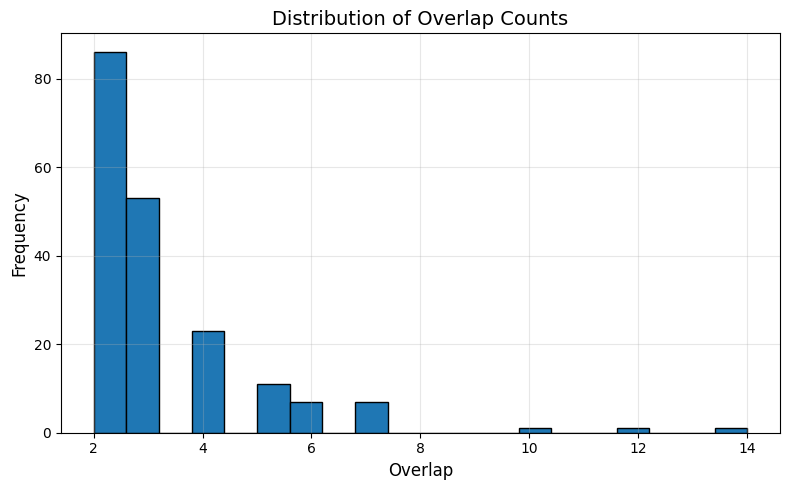

In [37]:
# Extract overlap numerator
overlap = (
    enrich_train['Overlap']
    .str.split('/')
    .str[0]
    .astype(int)
)

# Plot
plt.figure(figsize=(8, 5))
plt.hist(overlap, bins=20, edgecolor='black')

plt.title('Distribution of Overlap Counts', fontsize=14)
plt.xlabel('Overlap', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
# Create output dataframe
out_df = pd.DataFrame({
    'GO_ID': (
        enrich_train.loc[
            enrich_train['Gene_set'].str.contains('GO', na=False),
            'Term'
        ]
        .str.split(r'\(').str[1]
        .str.strip()
        .str[:-1]
    ),
    'Adjusted_P_value': enrich_train.loc[
        enrich_train['Gene_set'].str.contains('GO', na=False),
        'Adjusted P-value'
    ].values
})

# Save as tab-separated text file
out_df.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/src/anaylisis/go_c81.txt', sep='\t', index=False)

In [54]:
enrich_train

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,cytokine-mediated signaling pathway (GO:0019221),10/621,5.563579e-11,3.966832e-08,0,0,35.224586,831.729781,NFKBIA;CSF3;CD40;IL6;CD40LG;TNFRSF8;TNFSF8;GAT...
1,GO_Biological_Process_2021,cellular response to tumor necrosis factor (GO...,7/194,3.309284e-10,1.179760e-07,0,0,61.745989,1347.860552,NFKBIA;CD40;CD40LG;TNFRSF8;TNFSF8;GATA3;TP53
2,GO_Biological_Process_2021,tumor necrosis factor-mediated signaling pathw...,6/116,8.521945e-10,2.025382e-07,0,0,83.374825,1741.133676,NFKBIA;CD40;CD40LG;TNFRSF8;TNFSF8;TP53
3,GO_Biological_Process_2021,regulation of endothelial cell apoptotic proce...,4/44,7.706565e-08,1.102281e-05,0,0,132.940000,2177.372165,CD40;CD40LG;GATA3;ICAM1
4,GO_Biological_Process_2021,positive regulation of DNA-binding transcripti...,6/246,7.729879e-08,1.102281e-05,0,0,37.963462,621.673985,NFKBIA;CSF3;CD40;IL6;CD40LG;CFLAR
...,...,...,...,...,...,...,...,...,...,...
999,Reactome_2022,Transcriptional Regulation By VENTX R-HSA-8853884,2/39,6.204272e-04,5.864038e-03,0,0,63.414944,468.325851,IL6;TP53
1000,Reactome_2022,TAK1-dependent IKK And NF-kappa-B Activation R...,2/45,8.261016e-04,7.563993e-03,0,0,54.549932,387.238662,NFKBIA;TP53
1001,Reactome_2022,Ub-specific Processing Proteases R-HSA-5689880,3/201,8.605047e-04,7.640239e-03,0,0,18.733902,132.223716,NFKBIA;GATA3;TP53
1002,Reactome_2022,Programmed Cell Death R-HSA-5357801,3/208,9.500596e-04,8.187278e-03,0,0,18.087805,125.872778,MAPK1;CFLAR;TP53


In [33]:
for i in data_C['train_pos_genes'].tolist():
    print(i)

O15519
P04637
P05231
P05362
P09211
P09488
P09919
P13995
P18031
P22309
P23771
P25942
P25963
P28482
P28908
P29965
P32971
Q04864
Q8IXV7


In [38]:
enrich_traindd57, enrich_late ,enrich_geo_ppi , enrich_overlap_t_p1, enrich_overlap_t_p2,enrich_overlap_p2_p1= general_report(data_D57,'late_fused','mid_geo_fused_ppi',150)

late_fused TP position:  [('P00751', ['CFB'], 345)]
mid_geo_fused_ppi TP position:  [('P00751', ['CFB'], 141)]
overlaps gene numbers between top predictions:  78
train positive numbers:  21
overlap train enrich & late_fused enrich 29 
 overlap train enrich & mid_geo_fused_ppi enrich 33 
 overlap late_fused enrich & mid_geo_fused_ppi enrich 327


In [56]:
# Create output dataframe
out_df = pd.DataFrame({
    'GO_ID': (
        enrich_traindd57.loc[
            enrich_traindd57['Gene_set'].str.contains('GO', na=False),
            'Term'
        ]
        .str.split(r'\(').str[1]
        .str.strip()
        .str[:-1]
    ),
    'Adjusted_P_value': enrich_traindd57.loc[
        enrich_traindd57['Gene_set'].str.contains('GO', na=False),
        'Adjusted P-value'
    ].values
})

# Save as tab-separated text file
out_df.to_csv('/itf-fi-ml/shared/users/ziyuzh/svm/src/anaylisis/go_d57.txt', sep='\t', index=False)

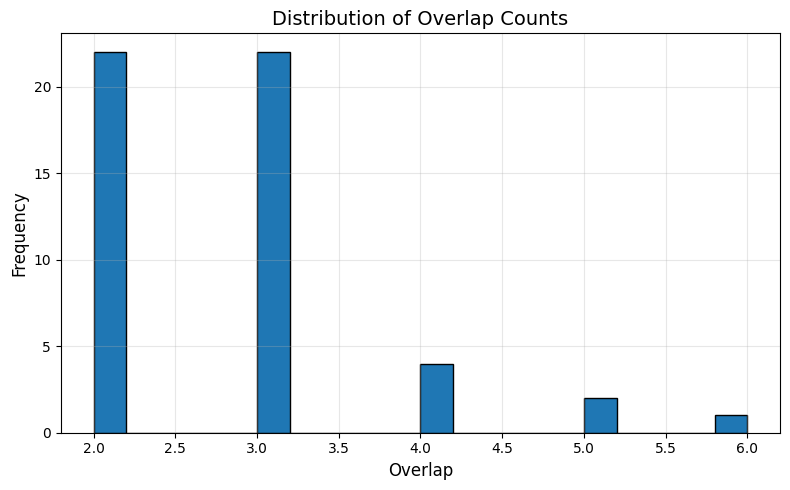

In [39]:
# Extract overlap numerator
overlap = (
    enrich_traindd57['Overlap']
    .str.split('/')
    .str[0]
    .astype(int)
)

# Plot
plt.figure(figsize=(8, 5))
plt.hist(overlap, bins=20, edgecolor='black')

plt.title('Distribution of Overlap Counts', fontsize=14)
plt.xlabel('Overlap', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [150]:
enrich_train

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,hydrogen peroxide catabolic process (GO:0042744),4/21,5.311911e-09,3.038232e-06,0,0,276.290657,5264.252683,GPX1;HBG2;HBE1;HBB
1,GO_Biological_Process_2021,pyrimidine nucleobase biosynthetic process (GO...,3/5,9.961417e-09,3.038232e-06,0,0,1664.750000,30672.263741,CAD;UMPS;DHODH
2,GO_Biological_Process_2021,hydrogen peroxide metabolic process (GO:0042743),4/29,2.096595e-08,4.247874e-06,0,0,187.802353,3320.414393,GPX1;HBG2;HBE1;HBB
3,GO_Biological_Process_2021,pyrimidine ribonucleotide biosynthetic process...,3/7,3.481864e-08,4.247874e-06,0,0,832.291667,14293.038809,CAD;UMPS;DHODH
4,GO_Biological_Process_2021,pyrimidine-containing compound biosynthetic pr...,3/7,3.481864e-08,4.247874e-06,0,0,832.291667,14293.038809,CAD;UMPS;DHODH
5,GO_Biological_Process_2021,response to hydrogen peroxide (GO:0042542),4/49,1.845087e-07,1.875839e-05,0,0,104.230065,1616.146481,GPX1;HP;HBB;NFE2L2
6,GO_Biological_Process_2021,pyrimidine nucleoside biosynthetic process (GO...,3/14,3.604189e-07,3.140794e-05,0,0,302.545455,4488.563991,CAD;UMPS;DHODH
7,GO_Biological_Process_2021,pyrimidine nucleoside metabolic process (GO:00...,3/15,4.502209e-07,3.432935e-05,0,0,277.319444,4052.615301,CAD;UMPS;DHODH
8,GO_Biological_Process_2021,regulation of lipid storage (GO:0010883),3/22,1.516663e-06,1.027961e-04,0,0,175.087719,2345.999993,C3;APOB;TNF
9,GO_Biological_Process_2021,regulation of nitric-oxide synthase activity (...,3/39,8.897969e-06,5.427761e-04,0,0,92.328704,1073.753969,GCH1;NOS3;TNF


In [151]:
pos_genes = data_D57['train_pos_genes'].tolist()
pos_genes.extend(['P00751'])
enrich_pos = enriched_set(pos_genes)

In [158]:
enrich_pos[enrich_pos['Genes'].str.contains('CFB')]
all_pos_enrich = enrich_pos[enrich_pos['Genes'].str.contains('CFB')]['Term']

In [ ]:
enrich_train[enrich_train['Term'].isin(all_pos_enrich)]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes


In [155]:
print(len(enrich_late))
enrich_late[enrich_late['Term'].isin(all_pos_enrich)]

564


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
1854,KEGG_2019_Human,Staphylococcus aureus infection,8/68,4.415318e-08,3.951710e-07,0,0,18.451282,312.483548,IL10;C4A;C5;HLA-DPB1;PLG;HLA-DQA1;HLA-DRB1;ICAM1
2088,Reactome_2022,Activation Of C3 And C5 R-HSA-174577,2/6,8.326603e-04,3.457121e-03,0,0,66.593960,472.210097,C4A;C5


In [156]:
print(len(enrich_geo_ppi))
enrich_geo_ppi[enrich_geo_ppi['Term'].isin(all_pos_enrich)]

912


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
2747,KEGG_2019_Human,Staphylococcus aureus infection,6/68,0.000012,0.000038,0,0,13.206007,149.117663,IL10;SELP;ITGAM;PLG;CFB;ICAM1


conclusion: D57 - Sickle-cell disorders, with clear sub-disease classes
late_fused with high biosim is actually better capture test positive related pathways